# Global Weather Trend Forecasting Assessment
### Mounika Teppola
### Data Scientist Intern

This project was completed as part of a Data Scientist internship assessment to analyze global weather trends, build forecasting models and generate climate insights using machine learning.

## Install & Importation of important Libraries

In [53]:
!pip install -q xgboost

In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor

## Basic Assessment

### SECTION 1: Data Cleaning & Preprocessing

This section loads the Global Weather Repository dataset and performs an initial data quality assessment using shape, column information, summary statistics and missing value checks. Numerical missing values are imputed using median values, while categorical missing values are filled using the most frequent category.

Duplicate records are removed, the `last_updated` column is converted to datetime format for time series analysis and outliers are filtered using the IQR method. Finally, numerical features are standardized using `StandardScaler` to prepare the dataset for modeling.

In [1]:
df = pd.read_csv('/content/GlobalWeatherRepository.csv')
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [2]:
df.shape

(137998, 41)

In [3]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137998 entries, 0 to 137997
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       137998 non-null  object 
 1   location_name                 137998 non-null  object 
 2   latitude                      137998 non-null  float64
 3   longitude                     137998 non-null  float64
 4   timezone                      137998 non-null  object 
 5   last_updated_epoch            137998 non-null  int64  
 6   last_updated                  137998 non-null  object 
 7   temperature_celsius           137998 non-null  float64
 8   temperature_fahrenheit        137998 non-null  float64
 9   condition_text                137998 non-null  object 
 10  wind_mph                      137998 non-null  float64
 11  wind_kph                      137998 non-null  float64
 12  wind_degree                   137998 non-nul

In [5]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,137998.000000,137998.000000,1.379980e+05,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,...,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000,137998.000000
mean,19.212225,21.953039,1.746560e+09,21.255475,70.261636,8.003661,12.884303,168.803186,1014.060059,29.944584,...,18.225443,457.195794,57.905565,14.939796,10.271949,24.081108,48.149297,1.695206,2.596009,49.488768
std,24.414769,65.786938,1.772477e+07,9.679729,17.423381,7.182681,11.556173,103.791000,10.292948,0.303902,...,13.764347,753.002883,30.650472,23.578463,35.345055,36.634374,148.418597,0.937734,2.435878,35.004724
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731229e+09,15.800000,60.400000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,200.300000,38.000000,1.700000,1.110000,7.050000,9.950000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.746608e+09,23.900000,75.000000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,292.300000,55.000000,5.650000,2.405000,14.060000,19.850000,1.000000,2.000000,49.000000
75%,40.400000,49.882200,1.761896e+09,28.000000,82.400000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.200000,456.950000,74.000000,17.250000,8.250000,27.750000,41.255000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.777271e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


For numeric columns:

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

For categorical:

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

In [13]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [14]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

### Section 2: Exploratory Data Analysis (EDA)

This section explores key weather trends, distributions and relationships within the dataset using visual analysis. Histograms are used to examine the spread of temperature and precipitation values, while time-based plots reveal how average weather conditions change over time.

A correlation heatmap is generated to identify relationships among numerical weather variables and country-level comparisons highlight the hottest regions based on average temperature. These analyses help uncover meaningful patterns before predictive modeling.

In [15]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [16]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

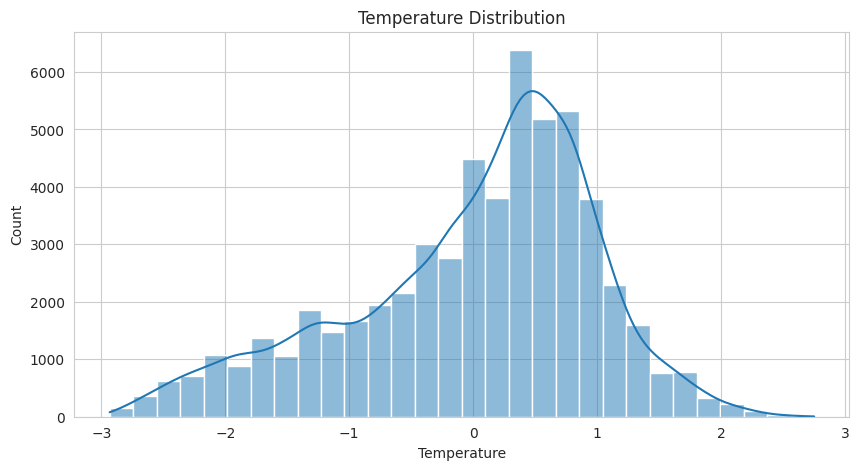

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df['temperature_celsius'], bins=30, kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.show()

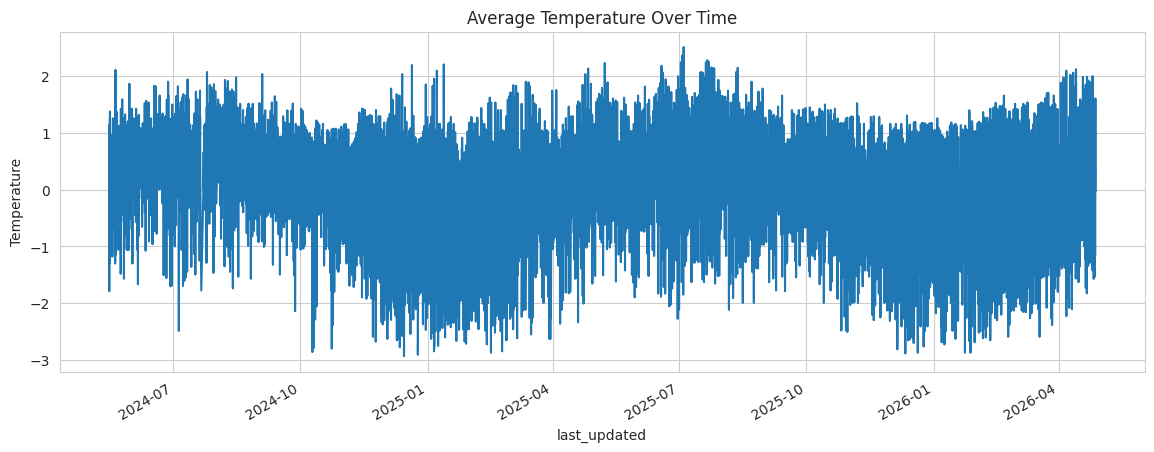

In [18]:
temp_trend = df.groupby('last_updated')['temperature_celsius'].mean()

plt.figure(figsize=(14,5))
temp_trend.plot()
plt.title("Average Temperature Over Time")
plt.ylabel("Temperature")
plt.show()

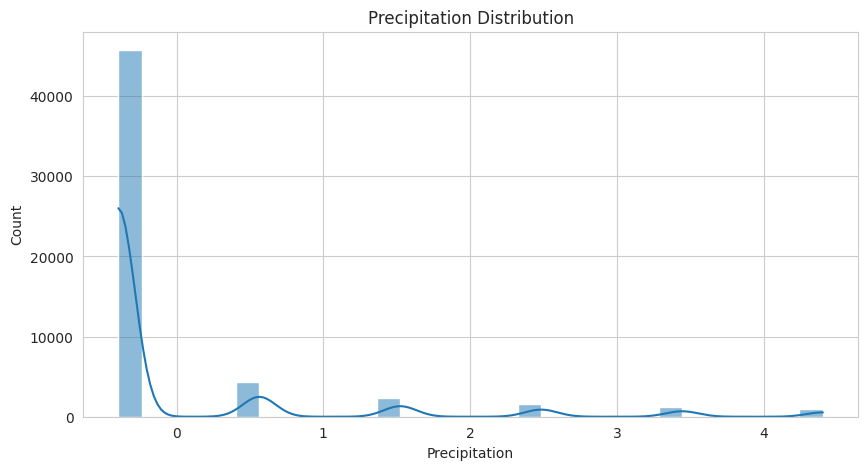

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df['precip_mm'], bins=30, kde=True)
plt.title("Precipitation Distribution")
plt.xlabel("Precipitation")
plt.show()

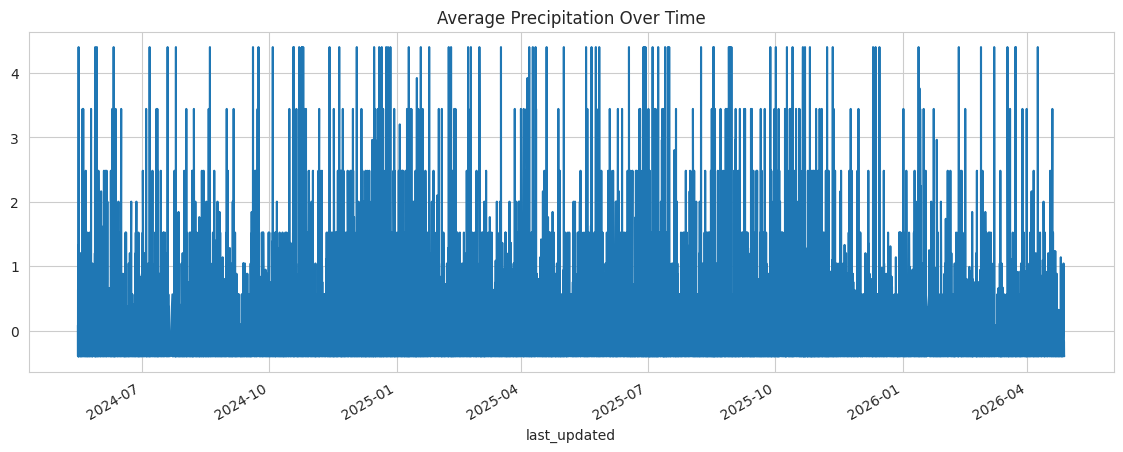

In [20]:
rain_trend = df.groupby('last_updated')['precip_mm'].mean()

plt.figure(figsize=(14,5))
rain_trend.plot()
plt.title("Average Precipitation Over Time")
plt.show()

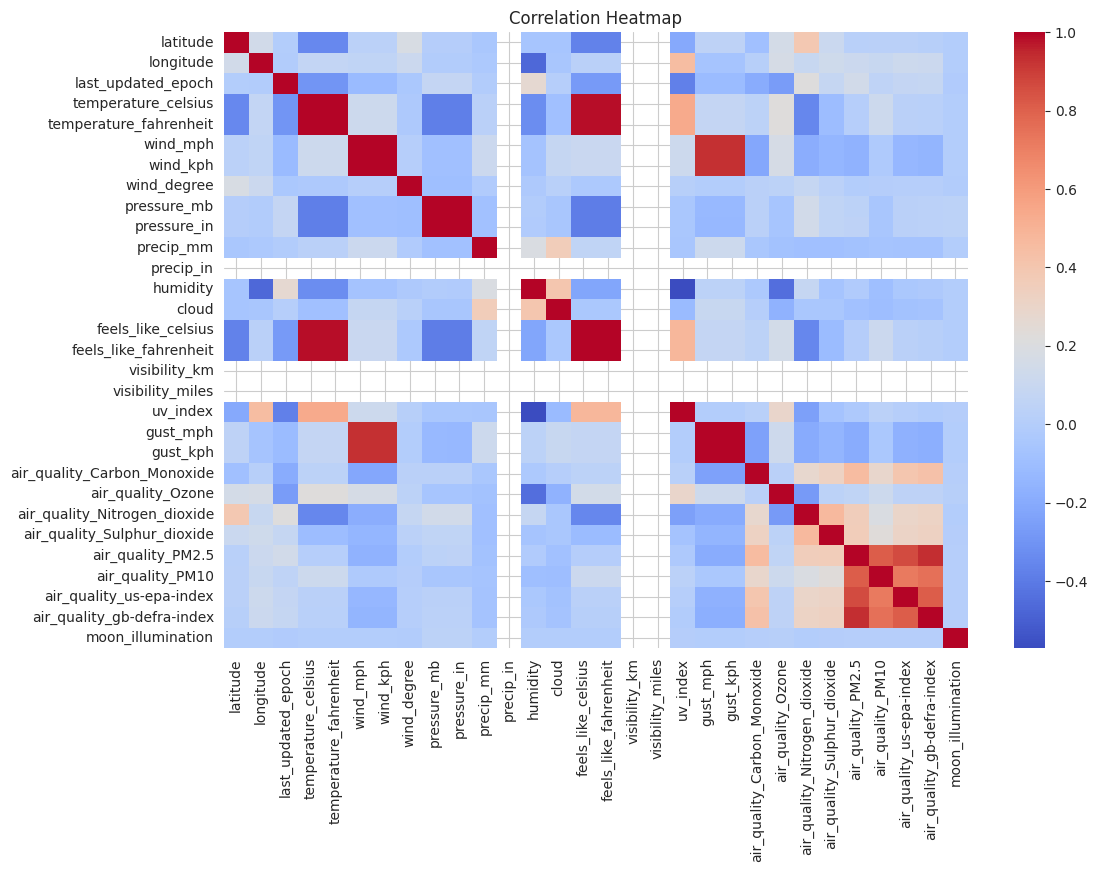

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

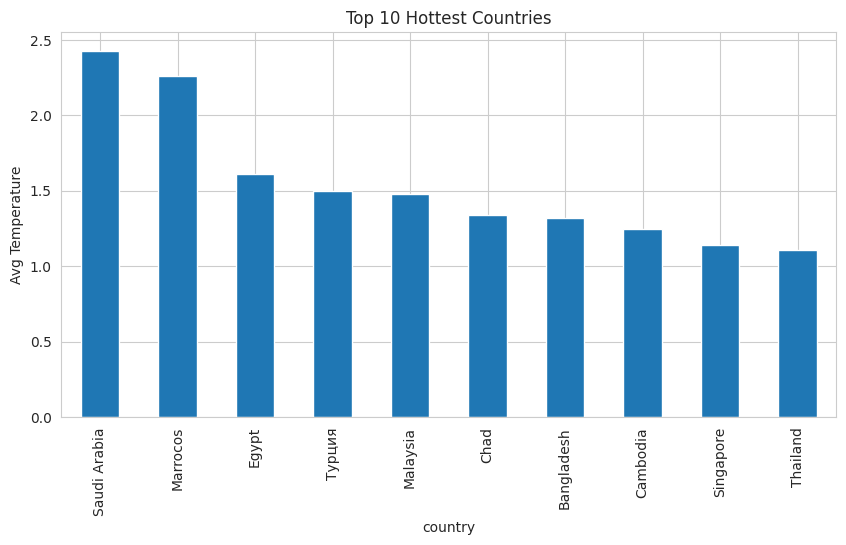

In [22]:
top_hot = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_hot.plot(kind='bar')
plt.title("Top 10 Hottest Countries")
plt.ylabel("Avg Temperature")
plt.show()

### SECTION 3: Forecasting Model Building

This section builds a baseline time series forecasting model by aggregating average daily temperature and converting dates into a numerical time feature `days`. The data is split chronologically into training and testing sets to preserve time order.

A Linear Regression model is trained to predict future temperature trends and evaluated using MAE, RMSE and R² metrics. Actual vs predicted values are visualized and a short-term 7-day future forecast is also generated.

In [23]:
forecast_df = df.groupby('last_updated')['temperature_celsius'].mean().reset_index()
forecast_df.head()

,last_updated,temperature_celsius
0,2024-05-16 02:45:00,0.596941
1,2024-05-16 03:45:00,-0.620120
2,2024-05-16 04:45:00,0.196247
3,2024-05-16 05:45:00,-1.788500
4,2024-05-16 07:45:00,0.037093


In [24]:
forecast_df['days'] = (forecast_df['last_updated'] - forecast_df['last_updated'].min()).dt.days
forecast_df.head()

,last_updated,temperature_celsius,days
0,2024-05-16 02:45:00,0.596941,0
1,2024-05-16 03:45:00,-0.620120,0
2,2024-05-16 04:45:00,0.196247,0
3,2024-05-16 05:45:00,-1.788500,0
4,2024-05-16 07:45:00,0.037093,0


In [25]:
train_size = int(len(forecast_df) * 0.8)

train = forecast_df[:train_size]
test = forecast_df[train_size:]

X_train = train[['days']]
y_train = train['temperature_celsius']

X_test = test[['days']]
y_test = test['temperature_celsius']

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.6717963491212477
RMSE: 0.9062893901166315
R2 Score: -0.06122451407562424


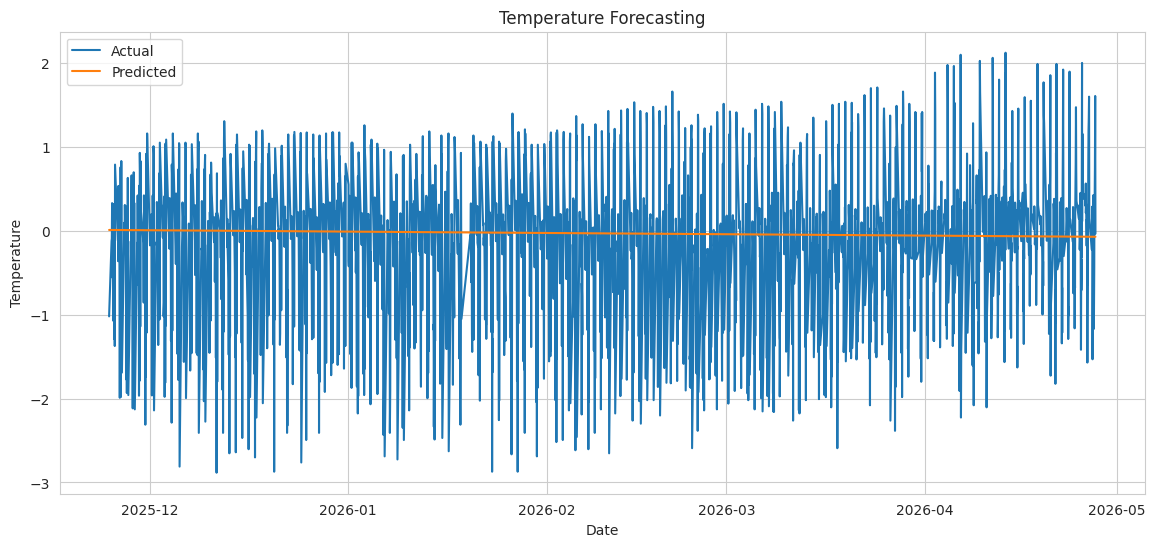

In [29]:
plt.figure(figsize=(14,6))
plt.plot(test['last_updated'], y_test, label='Actual')
plt.plot(test['last_updated'], y_pred, label='Predicted')
plt.title("Temperature Forecasting")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [30]:
future_days = pd.DataFrame({'days': range(forecast_df['days'].max()+1, forecast_df['days'].max()+8)})

future_pred = model.predict(future_days)
future_pred

array([-0.07428105, -0.07480904, -0.07533702, -0.07586501, -0.076393  ,
       -0.07692098, -0.07744897])

## Advanced Assessment

### Section 1: Advanced EDA



This section applies Isolation Forest, an unsupervised anomaly detection algorithm, to identify unusual weather observations using key atmospheric variables such as temperature, humidity, wind speed, pressure and precipitation.

Detected anomalies are separated from normal records and visualized to highlight rare or extreme weather conditions. This helps uncover hidden outliers that may represent unusual climate events or irregular sensor readings.

In [31]:
df.select_dtypes(include='number').columns

Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='object')

In [32]:
features = df[['temperature_celsius','humidity','wind_kph','pressure_mb','precip_mm']]

iso = IsolationForest(contamination=0.02, random_state=42)
df['anomaly'] = iso.fit_predict(features)

In [33]:
df['anomaly'].value_counts()

,count
anomaly,
1,55027
-1,1123


Temperature vs Precipitation

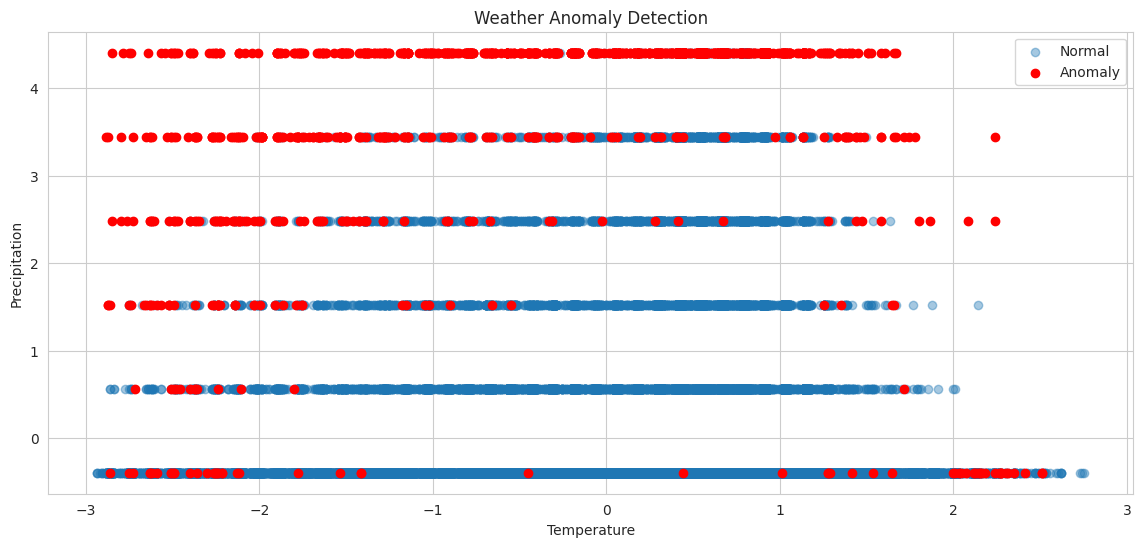

In [34]:
plt.figure(figsize=(14,6))

normal = df[df['anomaly']==1]
anomaly = df[df['anomaly']==-1]

plt.scatter(normal['temperature_celsius'], normal['precip_mm'], alpha=0.4, label='Normal')
plt.scatter(anomaly['temperature_celsius'], anomaly['precip_mm'], color='red', label='Anomaly')

plt.xlabel("Temperature")
plt.ylabel("Precipitation")
plt.title("Weather Anomaly Detection")
plt.legend()
plt.show()

### Section 2: Forecasting with Multiple Models

This section benchmarks multiple machine learning models, including linear, tree-based, boosting and ensemble approaches, to identify the most accurate method for temperature forecasting. Each model is trained on the prepared dataset and evaluated using MAE, RMSE and R² metrics.

Performance comparisons are visualized through bar charts and the best standalone model is identified. A weighted ensemble combining top-performing models (XGBoost, Gradient Boosting, and Random Forest) is then created to further improve predictive accuracy and overall model robustness.

In [56]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )
}

In [57]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

In [58]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

print("MODEL COMPARISON RESULTS")
display(results_df)

MODEL COMPARISON RESULTS


,Model,MAE,RMSE,R2
0,XGBoost,0.416319,0.537722,0.626416
1,Gradient Boosting,0.426806,0.548433,0.611384
2,Random Forest,0.419072,0.550064,0.609069
3,Extra Trees,0.419746,0.552420,0.605713
4,Linear Regression,0.451894,0.579871,0.565554
5,Ridge Regression,0.451892,0.579894,0.565519
6,AdaBoost,0.484153,0.625238,0.494915


In [59]:
best_model_name = results_df.iloc[0]["Model"]
best_r2 = results_df.iloc[0]["R2"]

print(f"Best Model: {best_model_name}")
print(f"Best R2 Score: {best_r2:.4f}")

Best Model: XGBoost
Best R2 Score: 0.6264


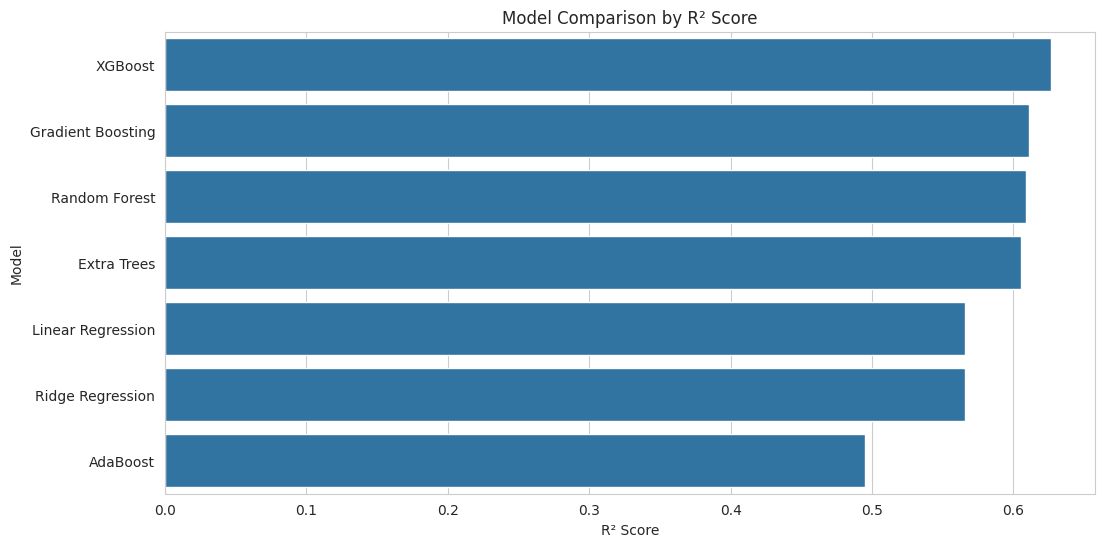

In [60]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)
plt.title("Model Comparison by R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()

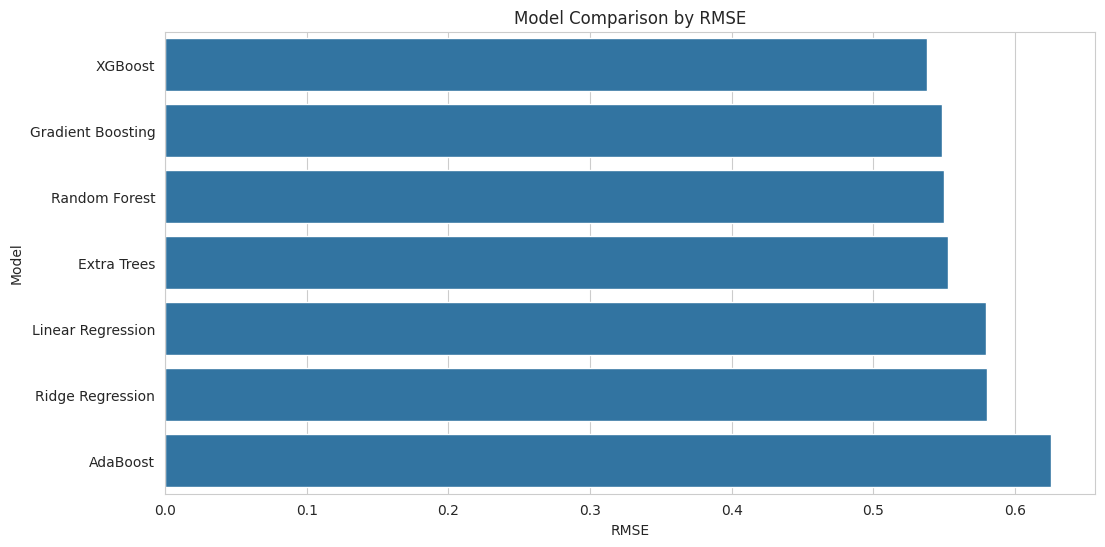

In [61]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=results_df.sort_values("RMSE"),
    x="RMSE",
    y="Model"
)
plt.title("Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

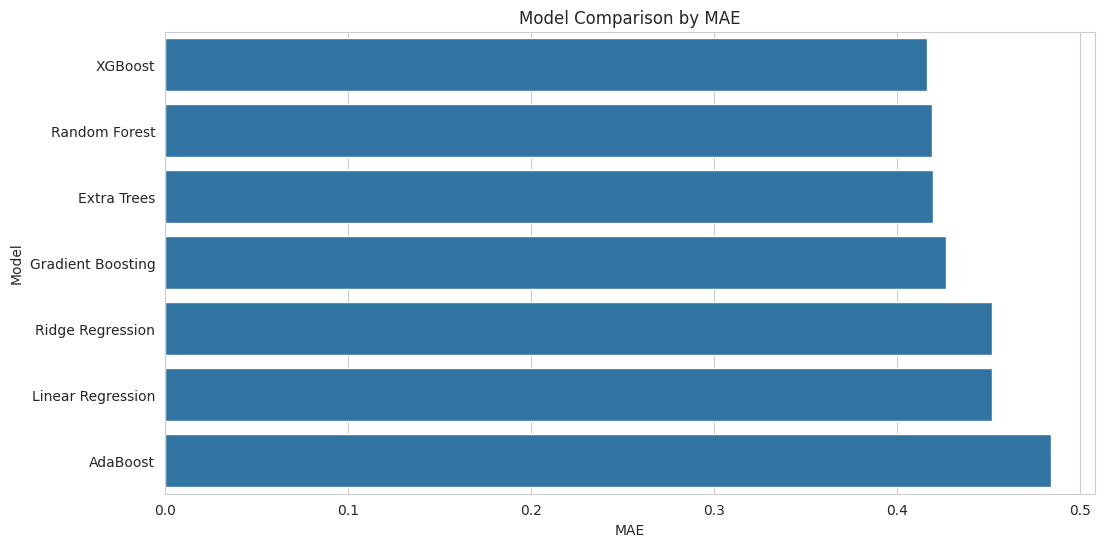

In [62]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=results_df.sort_values("MAE"),
    x="MAE",
    y="Model"
)
plt.title("Model Comparison by MAE")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.show()

In [64]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

gb = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [65]:
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
pred_gb = gb.predict(X_test)
pred_rf = rf.predict(X_test)

ensemble_pred = (
    pred_xgb * 0.5 +
    pred_gb * 0.3 +
    pred_rf * 0.2
)

In [66]:
mae = mean_absolute_error(y_test, ensemble_pred)
rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
r2 = r2_score(y_test, ensemble_pred)

print("FINAL ENSEMBLE RESULTS")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

FINAL ENSEMBLE RESULTS
MAE : 0.41387119991494487
RMSE: 0.534411395133901
R2  : 0.6310012441258357


In [67]:
ensemble_row = pd.DataFrame({
    "Model": ["Weighted Ensemble"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

all_results = pd.concat([results_df, ensemble_row], ignore_index=True)
top3_models = all_results.sort_values(by="R2", ascending=False).head(3)

print("TOP 3 PERFORMING MODELS")
display(top3_models.reset_index(drop=True))

TOP 3 PERFORMING MODELS


,Model,MAE,RMSE,R2
0,Weighted Ensemble,0.413871,0.534411,0.631001
1,XGBoost,0.416319,0.537722,0.626416
2,Gradient Boosting,0.426806,0.548433,0.611384


## Unique Analyses

#### Step 1: Climate Analysis

Global Temperature Trend Over Time

/tmp/ipykernel_5662/1161847553.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_climate = df.groupby(pd.Grouper(key='last_updated', freq='M'))['temperature_celsius'].mean().reset_index()


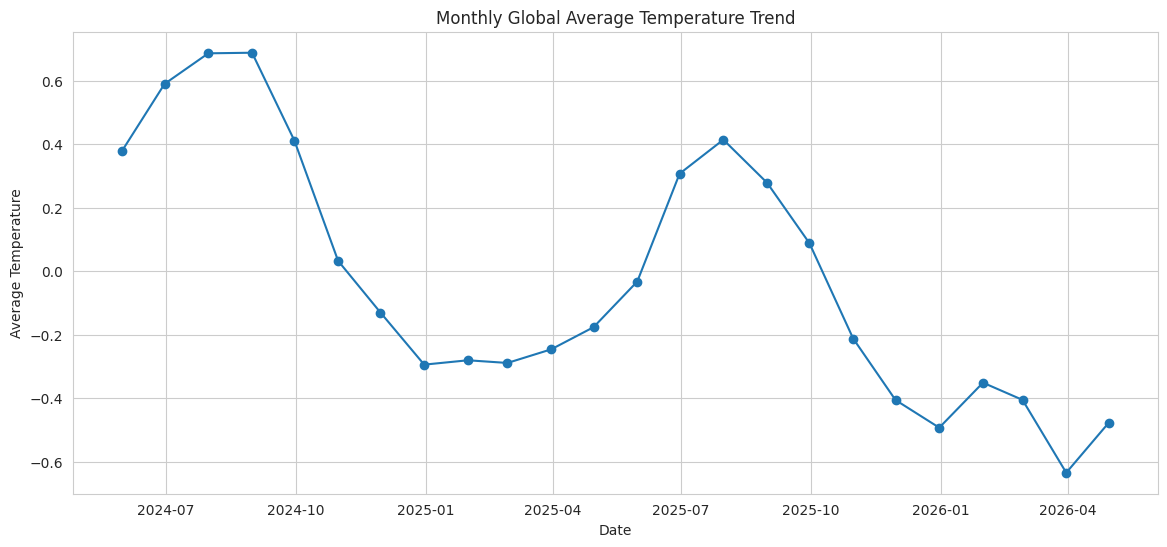

In [69]:
monthly_climate = df.groupby(pd.Grouper(key='last_updated', freq='M'))['temperature_celsius'].mean().reset_index()

plt.figure(figsize=(14,6))
plt.plot(monthly_climate['last_updated'], monthly_climate['temperature_celsius'], marker='o')

plt.title("Monthly Global Average Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Average Temperature")
plt.show()

Region-wise Temperature Comparison

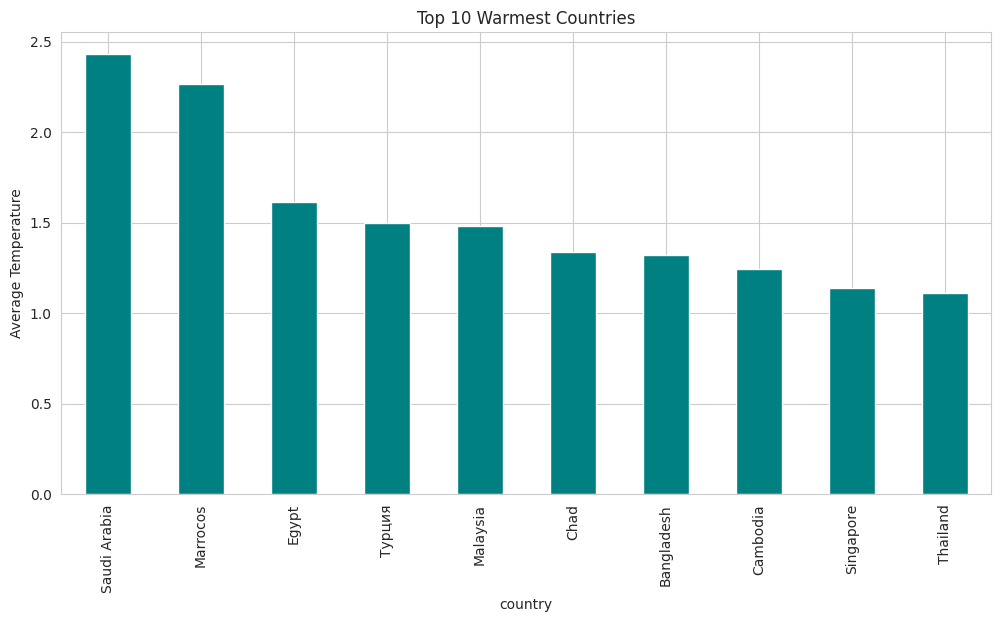

In [72]:
top_regions = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_regions.plot(kind='bar', color='teal')

plt.title("Top 10 Warmest Countries")
plt.ylabel("Average Temperature")
plt.show()

#### Step 2: Environmental Impact

AQI Correlation Heatmap

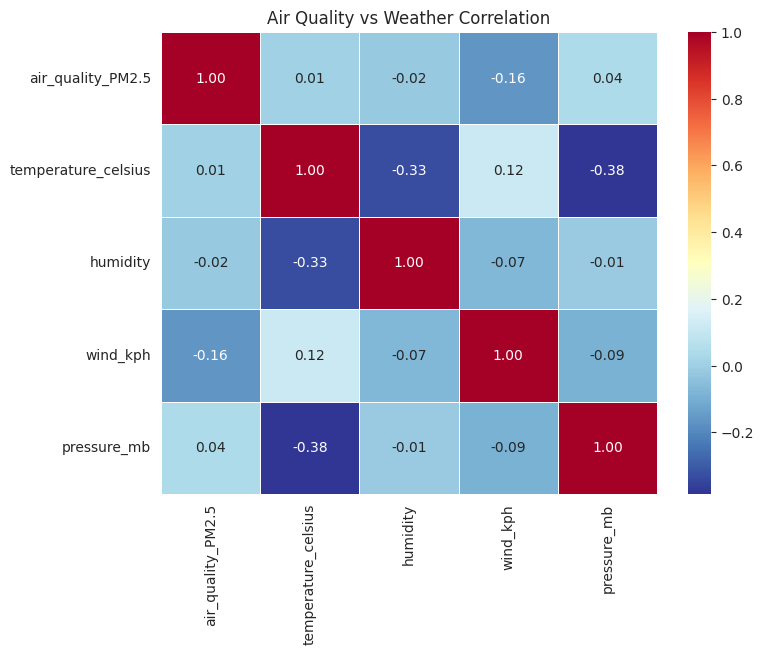

In [79]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[aqi_cols].corr(),
    annot=True,
    cmap='RdYlBu_r',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Air Quality vs Weather Correlation")
plt.show()

Hexbin Density Plot

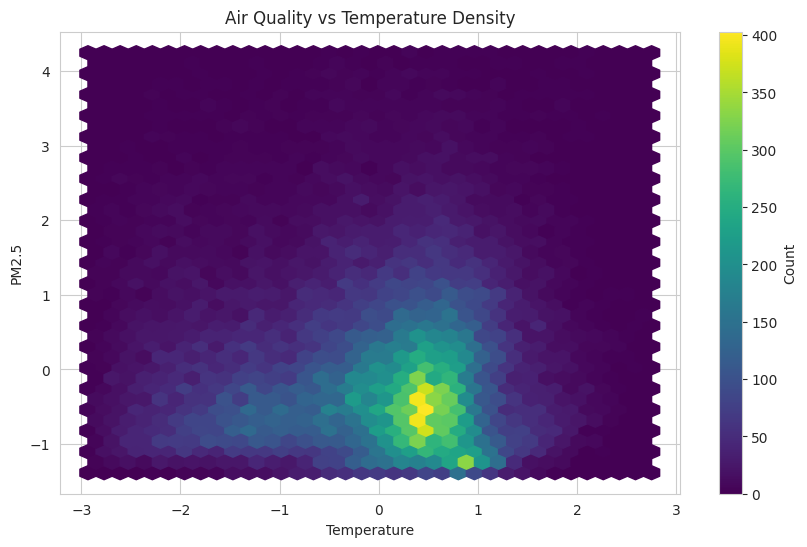

In [77]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df['temperature_celsius'],
    df['air_quality_PM2.5'],
    gridsize=35,
    cmap='viridis'
)

plt.colorbar(label='Count')
plt.title("Air Quality vs Temperature Density")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.show()

#### Step 3: Feature Importance

XGBoost Feature Importance

/tmp/ipykernel_5662/3603025664.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


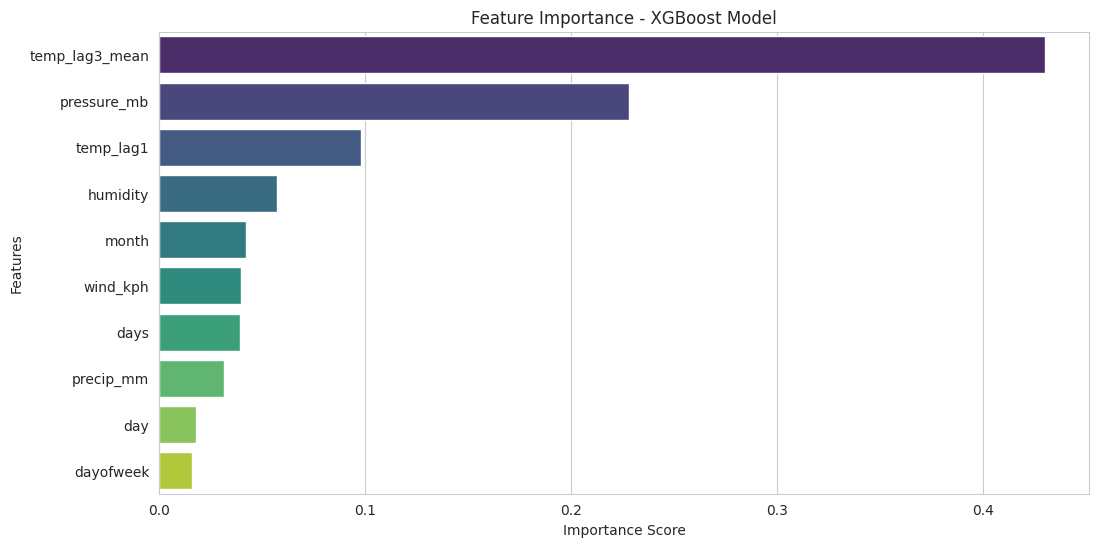

In [80]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Permutation Importance

/tmp/ipykernel_5662/4131167989.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_df, x="Importance", y="Feature", palette="magma")


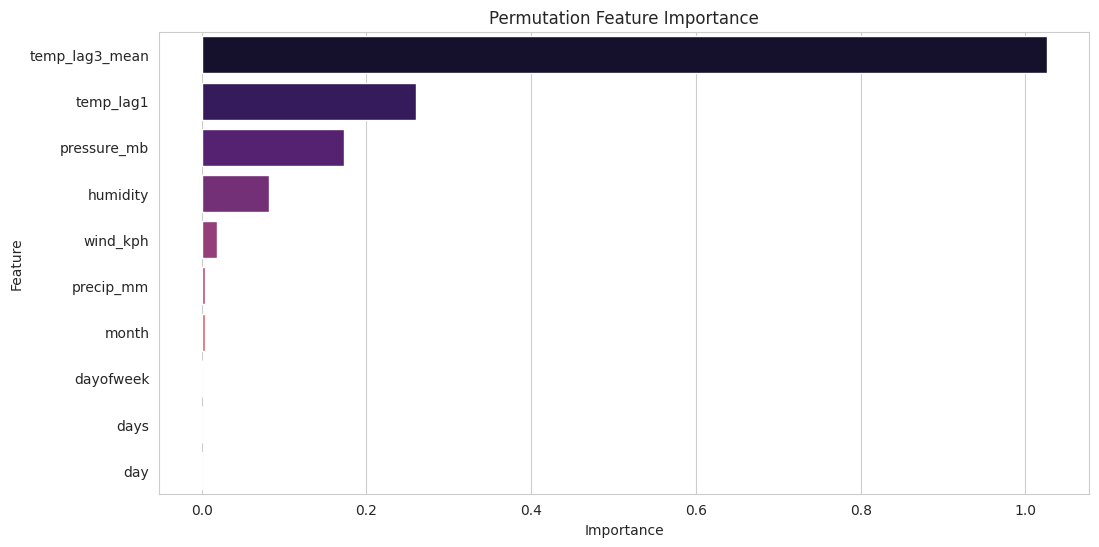

In [81]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=perm_df, x="Importance", y="Feature", palette="magma")

plt.title("Permutation Feature Importance")
plt.show()

#### Step 4: Spatial Analysis

Global Temperature Heat Distribution

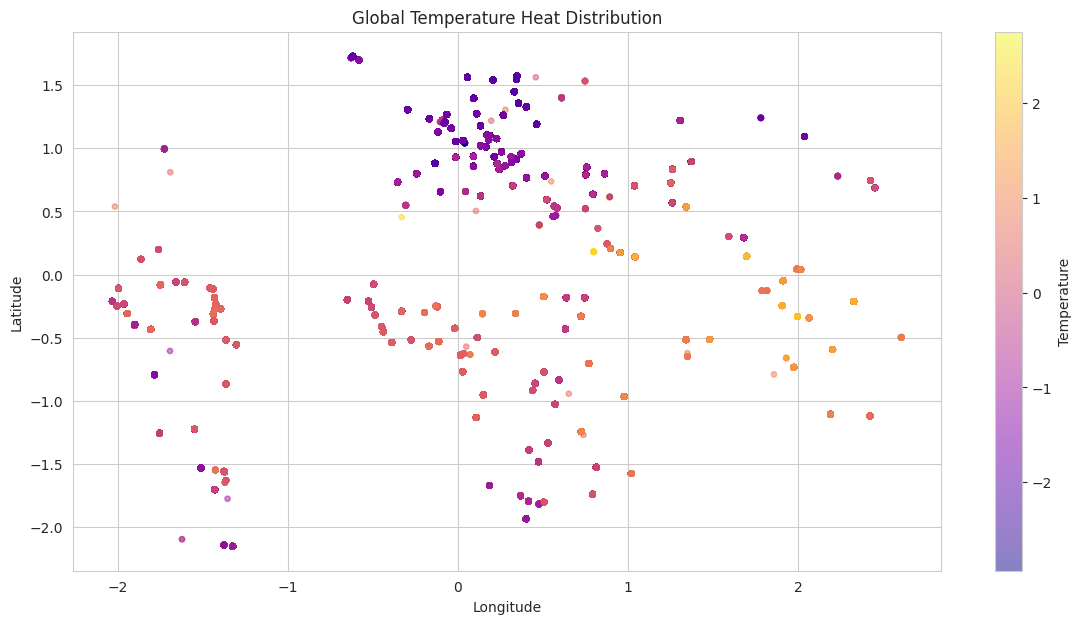

In [83]:
plt.figure(figsize=(14,7))

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['temperature_celsius'],
    cmap='plasma',
    alpha=0.5,
    s=15
)

plt.colorbar(label='Temperature')
plt.title("Global Temperature Heat Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Global Spatial Distribution of Rainfall

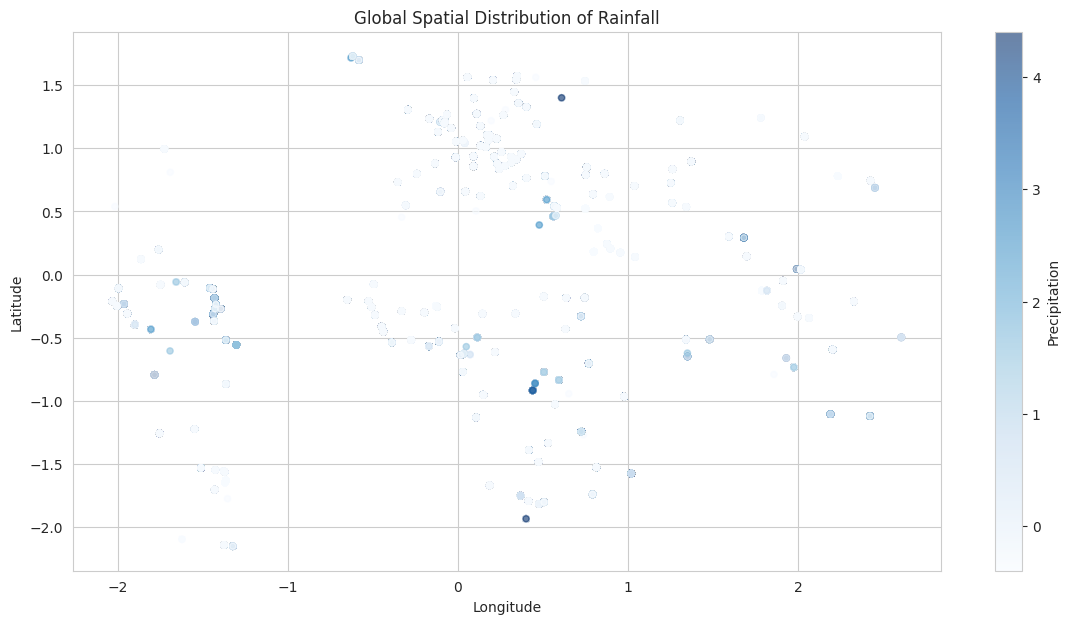

In [84]:
plt.figure(figsize=(14,7))

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['precip_mm'],
    cmap='Blues',
    alpha=0.6,
    s=20
)

plt.colorbar(label='Precipitation')

plt.title("Global Spatial Distribution of Rainfall")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

#### Step 5: Geographical Patterns

Top 10 Warmest Countries

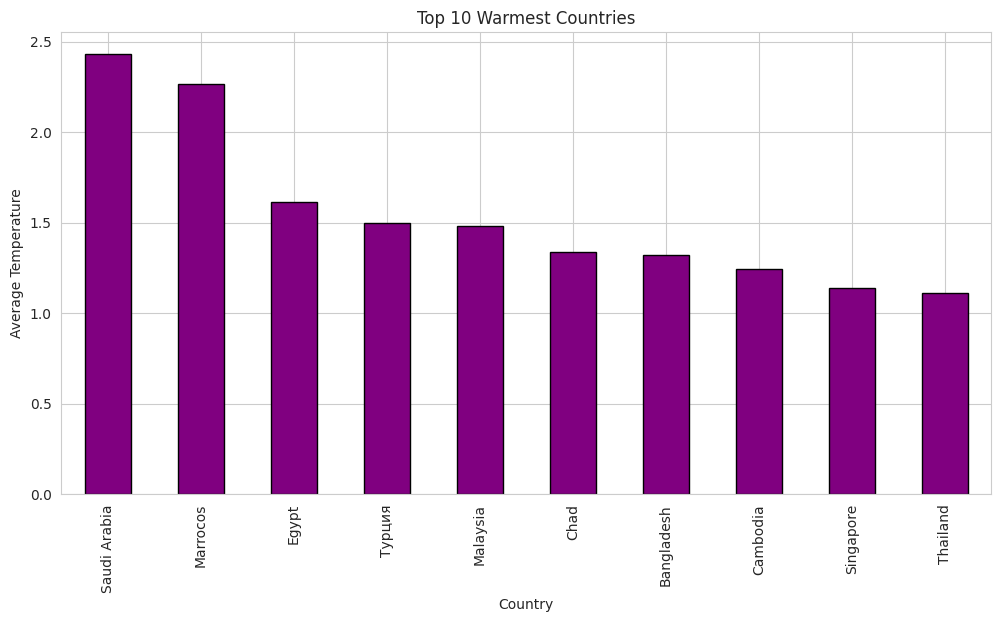

In [86]:
warmest = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
warmest.plot(kind='bar', color='purple', edgecolor='black')

plt.title("Top 10 Warmest Countries")
plt.ylabel("Average Temperature")
plt.xlabel("Country")
plt.show()

Top 10 Rainiest Countries

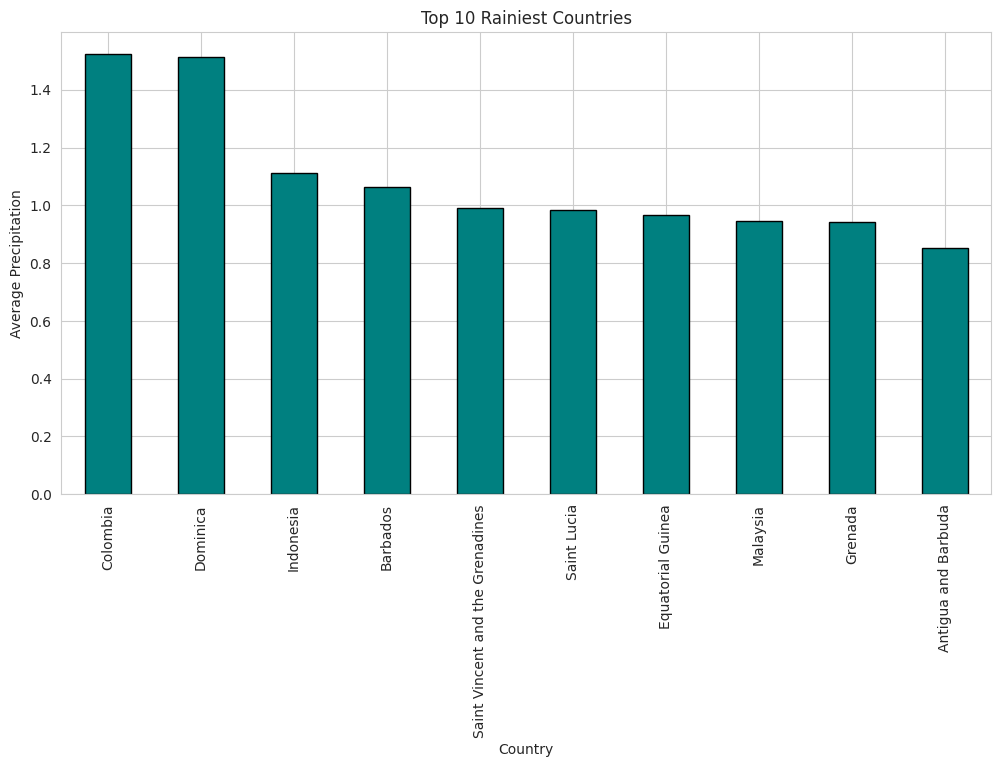

In [90]:
rainiest = df.groupby('country')['precip_mm'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
rainiest.plot(kind='bar', color='teal', edgecolor='black')

plt.title("Top 10 Rainiest Countries")
plt.ylabel("Average Precipitation")
plt.xlabel("Country")
plt.show()